# Lecture 2 · Notebook 2 — The debugging clinic

**ML Summer School · Large models: CNNs, GNNs, and deep learning applications**

---

### Where we are

Notebooks 0 and 1 were about **architecture**: choosing a hypothesis space that
matches the structure of your data. This notebook is about the other half of the
job, and it is the half you will actually spend your time on.

Here is the uncomfortable truth about deep learning in practice. You will design
a sensible architecture in an afternoon. You will then spend three weeks
discovering that it does not train, and the reason will almost never be the
architecture. It will be a learning rate, a missing shuffle, a normalisation
layer you left out of a network that turned out to be too deep to survive
without it.

Nobody teaches this, because it is not theory. It is diagnosis — and diagnosis is
a skill you already have. You have spent years looking at a plot of a quantity
against time and asking what physical process would produce that shape. That is
exactly the skill required here. The only thing you are missing is knowing which
quantities to plot and what the characteristic shapes mean.

### How this notebook works

1. We build an **instrument panel**: the five quantities worth logging on every
   run, and what a healthy training curve looks like.
2. You are then given **five patients** — five training runs that have gone
   wrong. You see only their curves. Diagnose each one before reading on.
3. We reveal each diagnosis and apply the fix. The fixes are, between them, the
   entire practical toolkit: learning-rate schedules, optimiser choice,
   normalisation layers, residual connections, shuffling, augmentation, weight
   decay, early stopping.
4. Twice we find that the textbook diagnosis is **wrong** on this data — once in
   the clinic, once with a classic bug that refuses to reproduce — and work out
   what is really going on. Knowing when a rule does *not* apply is worth more
   than the rule.
5. We finish with the history: which trick appeared at which scale, and what
   problem it was invented to solve.

You will get more out of this if you genuinely try to diagnose the five patients
before scrolling. Write down your guesses.

**Runtime:** roughly 20–25 minutes on a Colab T4 — the longest notebook in the
set, because it trains a lot of small models. If you are short of time, §3 (the
clinic) is the part that matters.

## 0. Setup

In [1]:
# Setup. Nothing here is part of the lecture -- it just makes `mlschool`
# importable (cloning the course repo if we are on Colab) and imports the usual
# suspects. Run it and move on.
REPO = "https://github.com/drinkingkazu/a3net-lecture2.git"
import os, subprocess, sys
try:
    import mlschool
except ModuleNotFoundError:
    here = [os.path.abspath(d) for d in (".", "..", "../..")]
    root = next((d for d in here
                 if os.path.isfile(os.path.join(d, "mlschool", "__init__.py"))), None)
    if root is None:                                   # not inside a checkout: fetch it
        subprocess.run(["git", "clone", "--depth", "1", REPO, "a3net-lecture2"], check=True)
        root = os.path.abspath("a3net-lecture2")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", root])
    sys.path.insert(0, root)

import mlschool as ms
import time
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
DEVICE = ms.device()
ms.hello()

mlschool 1.0.0 (/home/kazu/sw/ml_school/mlschool)  |  torch 2.8.0+cu128  |  device: cuda


In [2]:
train = ms.generate_dataset(3000, seed=0, progress=True)
val   = ms.generate_dataset(1000, seed=1)

CHARGE_SCALE = float(np.percentile(train["image"][train["image"] > 0], 99))
X  = torch.tensor(train["image"])[:, None] / CHARGE_SCALE
Y  = torch.tensor(train["label"])
XV = torch.tensor(val["image"])[:, None] / CHARGE_SCALE
YV = torch.tensor(val["label"])
print(f"train {tuple(X.shape)}   val {tuple(XV.shape)}   3-way event classification")

generating events:   0%|          | 0/3000 [00:00<?, ?it/s]

train (3000, 1, 96, 96)   val (1000, 1, 96, 96)   3-way event classification


## 1. The instrument panel

Most people log the training loss. The training loss alone is close to useless:
it tells you the optimiser is doing *something*, not whether it is doing the
right thing. Log these five instead.

| quantity | what it diagnoses |
|---|---|
| **training loss** | is the optimiser making progress at all? |
| **validation loss** | is that progress generalising, or is it memorisation? |
| **gradient norm** $\lVert g \rVert$ | exploding (huge, spiky) or vanishing (many orders of magnitude too small) gradients |
| **update ratio** $\lVert \Delta\theta \rVert / \lVert \theta \rVert$ | is the learning rate sane? Healthy is $\sim10^{-3}$ per step. $10^{-1}$ means you are destroying the model each step; $10^{-6}$ means nothing is happening |
| **dead-unit fraction** | fraction of ReLU outputs that are exactly zero. Creeping towards 1 means units have died and will never recover |

**Two resolutions.** The train-side quantities are computed on every step
anyway, so we record them **twenty times per epoch**; the validation numbers
need extra forward passes, so they stay at epoch boundaries. Both are plotted
against epochs, so the x-axis reads the same. This matters more than it sounds:
one of the patients below has structure *inside* each epoch that an epoch
average erases completely.

The **update ratio** deserves emphasis, because it is the single most useful
number and almost nobody logs it. It is dimensionless and roughly
architecture-independent, so unlike the learning rate it has a target value you
can memorise: **about $10^{-3}$**. If you only add one diagnostic to your code
after today, add that one.

In [3]:
class Block(nn.Module):
    """One conv-conv block, optionally with normalisation and a residual path."""

    def __init__(self, cin, ch, norm=True, residual=False):
        super().__init__()
        self.residual = residual and (cin == ch)
        layers = [nn.Conv2d(cin, ch, 3, padding=1)]
        if norm:
            layers.append(nn.BatchNorm2d(ch))
        layers += [nn.ReLU(), nn.Conv2d(ch, ch, 3, padding=1)]
        if norm:
            layers.append(nn.BatchNorm2d(ch))
        self.f = nn.Sequential(*layers)
        self.act = nn.ReLU()

    def forward(self, x):
        y = self.f(x)
        return self.act(y + x) if self.residual else self.act(y)


def make_net(n_blocks=4, ch=24, norm=True, residual=False, pool_every=1):
    """Our standard classifier. n_blocks=4 is 'normal'; n_blocks=10 is 'deep'."""
    layers = [nn.Conv2d(1, ch, 3, padding=1), nn.ReLU()]
    for i in range(n_blocks):
        layers.append(Block(ch, ch, norm, residual))
        if i % pool_every == pool_every - 1 and i < 8:
            layers.append(nn.MaxPool2d(2))
    layers += [nn.AdaptiveMaxPool2d(1), nn.Flatten(), nn.Linear(ch, 3)]
    return nn.Sequential(*layers)


print(make_net(n_blocks=4))

Sequential(
  (0): Conv2d(1, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Block(
    (f): Sequential(
      (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act): ReLU()
  )
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Block(
    (f): Sequential(
      (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (act

In [4]:
# Everything the clinic needs is in the package: `ms.fit_instrumented` runs one
# instrumented training run and returns the six logged series; `ms.plot_histories`
# draws the six-panel instrument panel. Read their source with
# `ms.training.fit_instrumented??` if you are curious -- but the *contents* of a
# training loop are not the lesson here, the curves are.
def experiment(name, model=None, **kw):
    """One instrumented run on our data. `model` may be a zero-argument factory,
    so the network is built after the seed is set and the run reproduces."""
    raw = kw.pop("raw_inputs", False)
    xtr = torch.tensor(train["image"])[:, None] if raw else X
    xva = torch.tensor(val["image"])[:, None] if raw else XV
    n = kw.pop("n_train", None) or len(xtr)
    return ms.fit_instrumented(name, model if model is not None else make_net,
                               xtr[:n], Y[:n], xva, YV, **kw)


plot_runs = ms.plot_histories          # same six panels, same healthy-band shading

## 2. What healthy looks like

Always establish the reference before you chase a bug. The green band in the
update-ratio panel marks the healthy $\sim10^{-3}$ region.

  ep 1/8  train 0.1953  val 1.3268  acc 0.343  |g| 1.53e+00  upd 1.6e-03
  ep 2/8  train 0.0486  val 0.2672  acc 0.906  |g| 1.07e+00  upd 8.0e-04
  ep 3/8  train 0.0252  val 0.0324  acc 0.997  |g| 5.87e-01  upd 7.2e-04
  ep 4/8  train 0.0231  val 0.0449  acc 0.991  |g| 1.02e+00  upd 6.7e-04
  ep 5/8  train 0.0108  val 0.0431  acc 0.989  |g| 2.18e-01  upd 9.5e-04
  ep 6/8  train 0.0064  val 0.0238  acc 0.996  |g| 2.28e-01  upd 3.8e-04
  ep 7/8  train 0.0109  val 0.0102  acc 0.997  |g| 4.18e-01  upd 5.5e-04
  ep 8/8  train 0.0030  val 0.0062  acc 1.000  |g| 6.92e-02  upd 3.7e-04
healthy                            final val acc 1.000   (16 s)


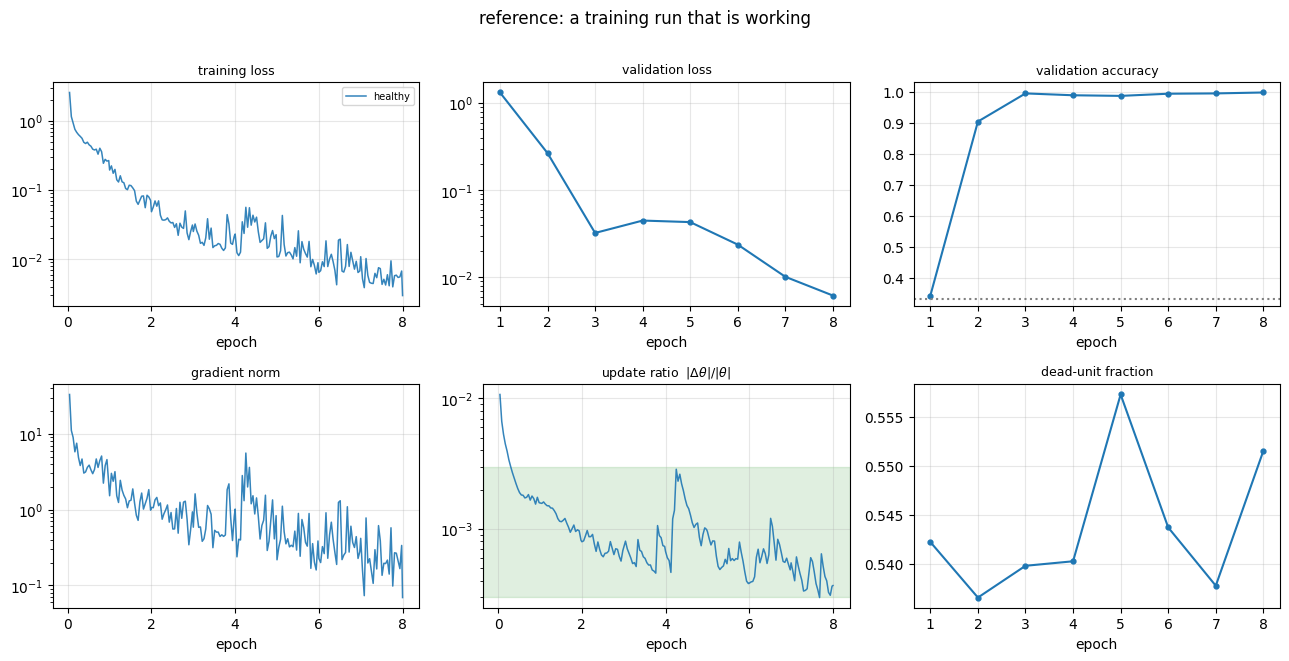

In [5]:
healthy = experiment("healthy", epochs=8, verbose=True)
plot_runs([healthy], "reference: a training run that is working")

Commit these shapes to memory:

- **training loss** falls and keeps falling. At twenty samples per epoch it is
  visibly jagged -- individual batches differ, and that scatter is normal. Read
  the trend, not the wiggle;
- **validation loss** tracks it, a little above, and does not turn upward;
- **gradient norm** is $O(1)$, decreasing gently, no spikes;
- **update ratio** sits in the $10^{-3}$ band;
- **dead-unit fraction** is substantial (~0.5 is normal for ReLU — half the
  pre-activations are negative) and **stable**. Drift towards 1.0 is the warning
  sign, not the absolute value.

## 3. The clinic

Five runs. Same data, same task, same architecture family. Each has exactly one
thing wrong with it.

**Look at the curves and write down your diagnosis before scrolling.** For each
patient, ask yourself in this order:

1. Is the training loss going down at all? (If not: optimisation problem.)
2. If it is, does validation follow? (If not: generalisation problem.)
3. What are the gradient norm and update ratio doing?

In [6]:
patients = [
    experiment("patient A", lr=3.0),
    experiment("patient B", lr=3e-6),
    experiment("patient C", model=lambda: make_net(n_blocks=10, norm=False, pool_every=3)),
    experiment("patient D", shuffle=False),
    experiment("patient E", n_train=200, epochs=8, bs=32),
]

patient A                          final val acc 0.327   (11 s)
patient B                          final val acc 0.485   (12 s)
patient C                          final val acc 0.327   (25 s)
patient D                          final val acc 0.363   (12 s)
patient E                          final val acc 0.341   (2 s)


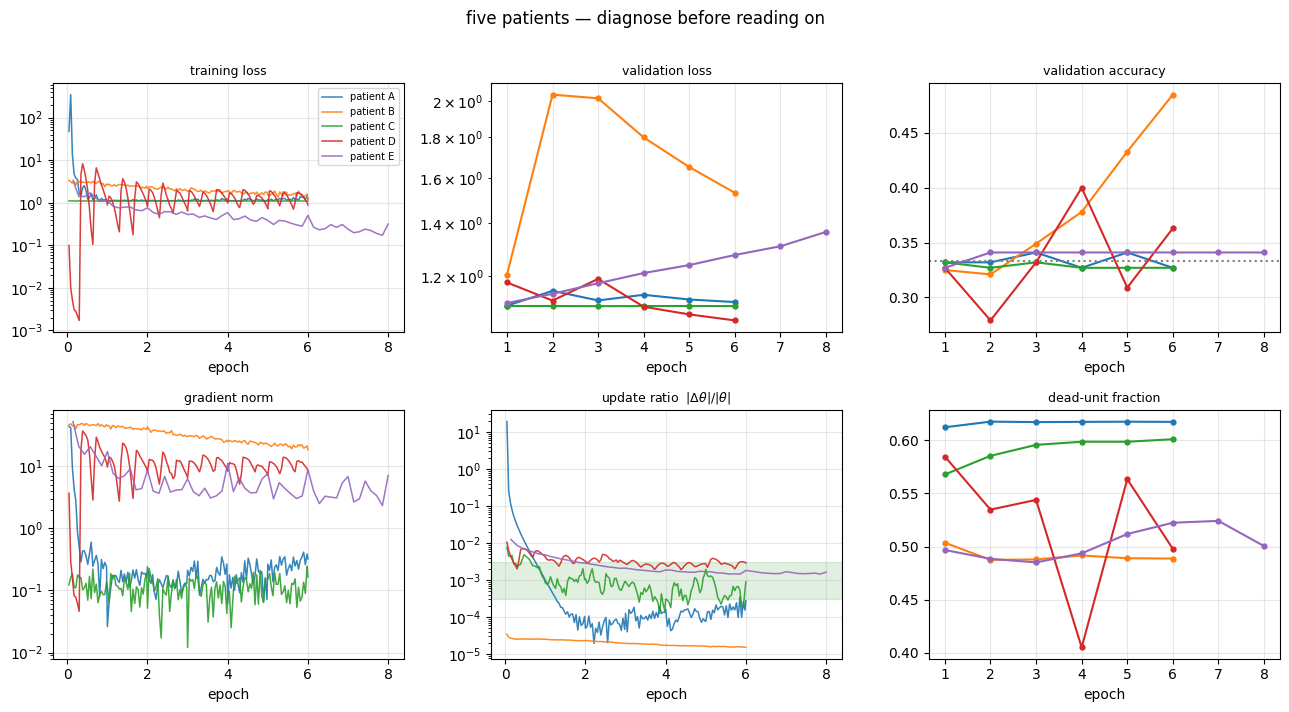

In [7]:
plot_runs(patients, "five patients — diagnose before reading on", figsize=(13, 7))

### ↓ Diagnoses below. Stop here if you have not written yours down. ↓

<br><br><br><br><br><br><br><br>

### Patient A — the learning rate is far too high

**Signature:** an enormous training loss in epoch 1 (ours is ~19), an update
ratio near $1$ — the parameters change by ~100 % in a single epoch — and then,
from epoch 2 onward, a loss pinned at $\ln 3 = 1.099$ with accuracy at exactly
chance.

**What is happening:** each step moves the parameters so far that the local
gradient information is meaningless; the optimiser is bouncing around the loss
surface at random. Within one epoch the model is wrecked, and it does not come
back: every unit is saturated or dead, so the gradient is now genuinely tiny and
the update ratio *collapses* to $10^{-4}$. That two-phase signature — a violent
first epoch followed by a dead flat line — is characteristic.

$\ln(3) = 1.0986$ is the loss of a model outputting a uniform distribution over
3 classes. Memorise the equivalent for your own problem: **a loss pinned at
$\ln(\text{n classes})$ means your model has collapsed to predicting nothing.**

Two warnings. First, the loss need not diverge to infinity — with adaptive
optimisers it often just sits there looking flat, which is easy to confuse with
patient B. Second, Adam is remarkably tolerant: at $\text{lr}=1.0$ this same
network *recovers* and reaches 76 % accuracy, looking merely unstable rather than
broken. Being "nearly fine" is how a bad learning rate survives to production.

**Fix:** lower it. And find out what "lower" should be, rather than guessing —
next section.

### Patient B — the learning rate is far too low

**Signature:** training loss decreases, but agonisingly slowly and perfectly
smoothly — ours goes 2.98 → 1.58 over six epochs, and accuracy crawls from 0.33
to 0.48. The update ratio is $\sim2\times10^{-5}$, two orders of magnitude below
healthy, and *flat*. Gradients are fine.

**This is the one people misdiagnose**, because it looks like "the model cannot
learn this task" — you conclude your architecture is wrong and start redesigning,
when all you needed was a bigger number. The update ratio distinguishes A from B
instantly: A is far above the band, B is far below it, and both look like a flat
accuracy curve.

**Fix:** raise it. Same tool as A.

### Patient C — too deep, with no normalisation and no residual connections

**Signature:** training loss is stuck at $\ln 3$, like patient A — but the
gradient norm tells a completely different story, and the update ratio is tiny.
Nothing is exploding; nothing is happening.

**What is happening:** this is a 21-layer plain convolutional network. Each layer
multiplies the backward-propagated gradient by a factor whose typical magnitude
is not exactly 1, and twenty such factors compound. Let us measure it directly
rather than assert it.

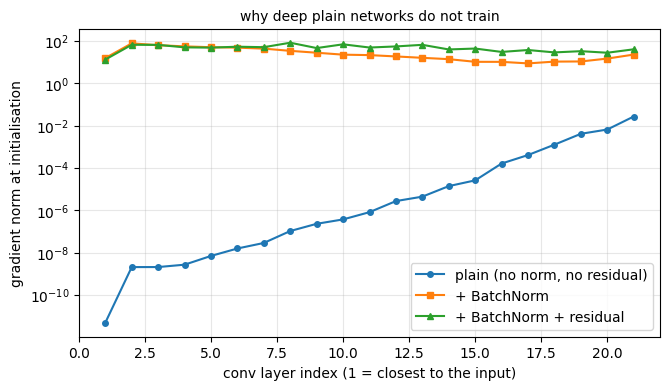

plain network: layer 1 gradient is 5.6e+09x SMALLER than the last layer's


In [8]:
def layer_gradients(model):
    """Gradient norm of each conv weight, from one batch, at initialisation."""
    model = model.to(DEVICE); model.train()
    F.cross_entropy(model(X[:64].to(DEVICE)), Y[:64].to(DEVICE)).backward()
    return [p.grad.norm().item() for p in model.parameters()
            if p.grad is not None and p.dim() == 4]


torch.manual_seed(0); g_plain = layer_gradients(make_net(10, norm=False, pool_every=3))
torch.manual_seed(0); g_bn    = layer_gradients(make_net(10, norm=True,  pool_every=3))
torch.manual_seed(0); g_res   = layer_gradients(make_net(10, norm=True, residual=True, pool_every=3))

fig, ax = plt.subplots(figsize=(7.5, 4))
for g, lab, st in [(g_plain, "plain (no norm, no residual)", "o-"),
                   (g_bn, "+ BatchNorm", "s-"),
                   (g_res, "+ BatchNorm + residual", "^-")]:
    ax.semilogy(range(1, len(g) + 1), g, st, ms=4, label=lab)
ax.set_xlabel("conv layer index (1 = closest to the input)")
ax.set_ylabel("gradient norm at initialisation")
ax.set_title("why deep plain networks do not train", fontsize=10)
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

print(f"plain network: layer 1 gradient is {g_plain[-1] / g_plain[0]:.1e}x "
      f"SMALLER than the last layer's")

Read that number again. In the plain network the gradient reaching the first
convolution is roughly **ten orders of magnitude** smaller than the gradient at
the last one. The early layers — the ones that have to learn what an ionisation
track looks like — receive numerically nothing. They are still at their random
initialisation when training ends.

With BatchNorm and residual connections the gradient norm is essentially **flat
across depth**. That is the entire point of both mechanisms, and it is why
networks went from 8 layers deep to 100+ in a single year.

- **Normalisation** rescales activations to a fixed distribution at every layer,
  so the forward signal cannot blow up or decay geometrically — and neither can
  the backward one.
- **Residual connections** $y = x + f(x)$ give the gradient an unobstructed path:
  $\partial y/\partial x = 1 + \partial f/\partial x$. That $1$ is a highway. Even
  if $f$ contributes nothing, the gradient arrives intact.

> Note this is a *different* job from the U-Net skips in Notebook 1. Those
> concatenate across a resolution gap to recover spatial detail. These add at the
> same resolution to keep gradients alive. Same nickname, unrelated mechanisms.

deep, +residual                    final val acc 0.984   (26 s)
deep, +BN                          final val acc 0.998   (32 s)
deep, +BN +res                     final val acc 0.993   (32 s)


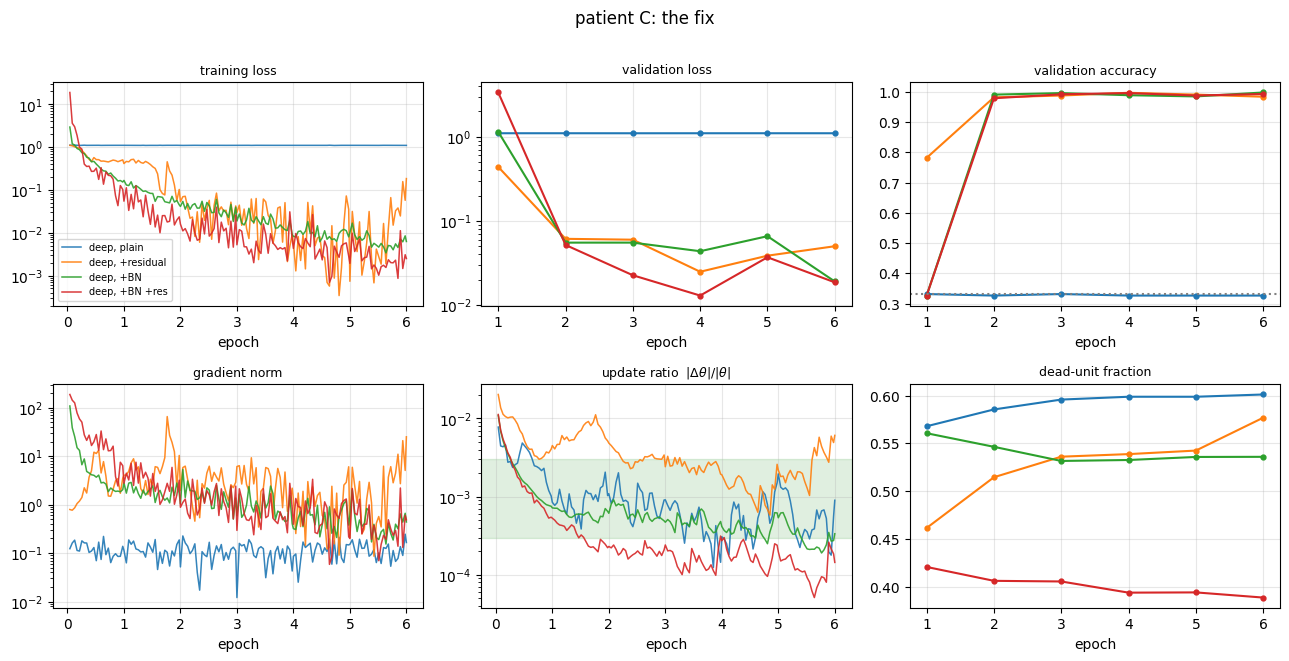

In [9]:
# patient C is already exactly the "deep, plain" configuration -- reuse it
# rather than paying to train the same network twice.
deep_fixes = [
    dict(patients[2], name="deep, plain"),
    experiment("deep, +residual", model=lambda: make_net(10, norm=False, residual=True,  pool_every=3)),
    experiment("deep, +BN",       model=lambda: make_net(10, norm=True,  residual=False, pool_every=3)),
    experiment("deep, +BN +res",  model=lambda: make_net(10, norm=True,  residual=True,  pool_every=3)),
]
plot_runs(deep_fixes, "patient C: the fix", figsize=(13, 6.5))

**Any one of them rescues the network.** Residual connections alone take it from
chance to ~0.99; BatchNorm alone does the same; both together, likewise. That
makes sense given the gradient plot: the two mechanisms attack the *same* problem
— the geometric decay of the gradient across depth — by different routes, and
either is enough to stop the early layers being starved.

Do not read anything into the third decimal place of the final numbers. Once the
network can train at all, this task is easy and every working configuration
saturates at the same place. **The interesting difference is not where they end
up, it is that the plain network never starts.**

So read the *shapes*, not the endpoints. The plain network's training loss is a
flat line at $\ln 3$ — nothing is happening, at any epoch. The other three
descend; compare how quickly they get going and how steady their validation
curves are, which is where you would see a difference on a harder problem.

Why does everyone use both in practice, then? Because real networks are deeper
than 21 layers and real tasks are harder than this one, and the two mechanisms
stop being redundant as you scale. **This combination is not an architectural
flourish; it is the load-bearing structure that makes depth possible at all.**

### Patient D — the data was never shuffled

**Signature:** look at the training-loss panel and *count the teeth*. The loss
falls, jumps, falls, jumps -- with a period of exactly one third of an epoch,
and we have exactly three classes. The gradient norm and the update ratio show
the same rhythm. Validation accuracy sits near chance.

That periodicity is the entire diagnosis, and it is only visible because we log
twenty times per epoch. Averaged over an epoch, all three panels collapse to a
merely "noisy" curve that could be a dozen different faults.

**What is happening:** we sorted the training set by class label. Every batch now
contains events of a single class -- which is why the period is one third of an
epoch: the model works through all the tracks, then all the showers, then all
the track+shower events, and the loss spikes each time the class changes under
it. Stochastic gradient descent assumes each
mini-batch is an unbiased sample of the training distribution; a single-class
batch is maximally biased. The model is repeatedly told "everything is a track",
then "everything is a shower", and it dutifully chases each in turn.

This is a stupid bug that is very easy to commit for real, because **data arrives
sorted**. Simulation output is grouped by production run. Detector data is
ordered by time, which correlates with calibration, beam conditions, and which
subdetectors were live. If you read files in order and do not shuffle, you have
built patient D.

There is a second, subtler casualty: **BatchNorm computes statistics over the
batch**. If your batch is not representative, neither are the statistics, and the
normalisation itself becomes a source of noise. This is the deep reason
BatchNorm's behaviour depends on how you construct your batches — and one of the
reasons LayerNorm, which normalises over features within each sample and is
completely independent of batch composition, took over in the transformer era.

D: unshuffled                      final val acc 0.344   (12 s)
D: shuffled                        final val acc 0.982   (12 s)


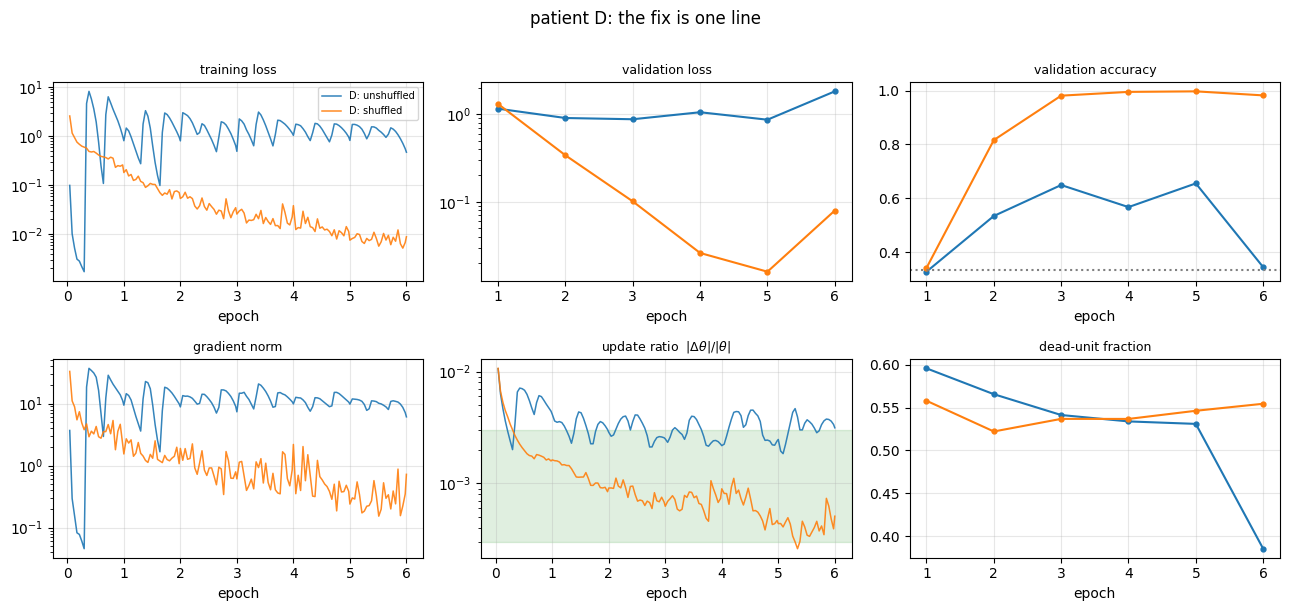

In [10]:
plot_runs([experiment("D: unshuffled", shuffle=False),
           experiment("D: shuffled", shuffle=True)],
          "patient D: the fix is one line", figsize=(13, 6))

### Patient E — only 200 training events. But *what* is wrong?

**Signature:** the *only* patient whose training loss looks great. It drops
towards zero. Meanwhile validation loss bottoms out and then **turns upward**,
and validation accuracy sits pinned at chance.

Train down, validation up. Every textbook — including the first draft of this
notebook — calls that the definitive signature of **overfitting**: the model has
enough capacity to memorise 200 events, memorisation is the path of least
resistance, and what it memorised does not transfer.

That diagnosis is wrong here, and finding out why is the most useful thing in
this section.

**The clue is the accuracy column.** Look at it again: it is not merely poor, it
is pinned at *exactly* the majority-class fraction for epoch after epoch, while
the training loss falls smoothly by a factor of seven. A model that had genuinely
memorised the training set would still be *right sometimes* on validation data —
a memorising model is a bad model, not a model that has never heard of the task.
Something is different between how we evaluate and how we train.

There is exactly one thing that behaves differently in `model.train()` and
`model.eval()`: **BatchNorm**. During training it normalises using the statistics
of the current batch. At evaluation it uses *running averages* accumulated during
training. With 200 events and a batch size of 32 we get 6 batches per epoch, so
those running averages are estimated from a handful of small, noisy samples — and
until they converge, the evaluation-time network is normalising with the wrong
constants and produces nonsense.

Let us test that directly: train once, and evaluate the same model both ways.

In [11]:
torch.manual_seed(0)
probe = make_net().to(DEVICE)
opt = torch.optim.Adam(probe.parameters(), lr=1e-3)
n_small = 200

print(f"{'epoch':>6}{'train loss':>12}{'val loss':>10}{'val acc':>9}"
      f"{'val loss':>12}{'val acc':>9}")
print(f"{'':>6}{'':>12}{'--- eval mode ---':>19}{'-- batch stats --':>21}")
for ep in range(16):
    probe.train()
    perm = torch.randperm(n_small)
    tot = 0.0
    for i in range(0, n_small, 32):
        b = perm[i:i + 32]
        if len(b) < 2:
            continue
        opt.zero_grad()
        loss = F.cross_entropy(probe(X[b].to(DEVICE)), Y[b].to(DEVICE))
        loss.backward(); opt.step()
        tot += loss.item() * len(b)

    row = []
    for train_mode in (False, True):          # eval mode, then batch statistics
        probe.train() if train_mode else probe.eval()
        vl, correct = 0.0, 0
        with torch.no_grad():
            for i in range(0, len(XV), 100):
                o = probe(XV[i:i + 100].to(DEVICE))
                vl += F.cross_entropy(o, YV[i:i + 100].to(DEVICE)).item() * len(o)
                correct += (o.argmax(1).cpu() == YV[i:i + 100]).sum().item()
        row += [vl / len(XV), correct / len(XV)]
    if ep < 8 or ep % 2 == 1:
        print(f"{ep + 1:>6}{tot / n_small:>12.4f}{row[0]:>10.4f}{row[1]:>9.3f}"
              f"{row[2]:>12.4f}{row[3]:>9.3f}")

 epoch  train loss  val loss  val acc    val loss  val acc
                    --- eval mode ---    -- batch stats --
     1      1.6825    1.1087    0.327      0.8595    0.604
     2      0.7534    1.1757    0.341      0.6746    0.761
     3      0.5775    1.2235    0.341      0.5750    0.769
     4      0.4745    1.2403    0.344      0.4861    0.808
     5      0.3946    0.8800    0.587      0.4276    0.831
     6      0.3090    0.5172    0.754      0.3850    0.850
     7      0.2556    0.3946    0.856      0.3302    0.893
     8      0.1965    0.3514    0.850      0.2984    0.916
    10      0.1240    0.2512    0.924      0.2651    0.910
    12      0.0806    0.2246    0.923      0.2105    0.934
    14      0.0458    0.1844    0.963      0.1791    0.945
    16      0.0263    0.1644    0.953      0.1668    0.954


There it is. Evaluated with **batch statistics**, the model is already at ~0.6
accuracy after one epoch and improves monotonically, and its validation loss
*falls* throughout. Evaluated in the normal way, with the running averages, the
same weights score chance for four epochs and the validation loss climbs.

**The model was learning correctly the entire time.** Nothing was overfitting.
The rising validation loss was an artefact of BatchNorm statistics estimated from
six batches per epoch.

> **This answers a question you should have been asking:** *if it were really
> overfitting, why would training it for longer make validation better?* It
> wouldn't. That is exactly the tell. Genuine overfitting does not spontaneously
> repair itself — so when a "textbook overfitting curve" reverses, your diagnosis
> was wrong.
>
> (In fairness, curves *can* legitimately go down-up-down: **epoch-wise double
> descent** is a real, documented phenomenon in overparameterised models. It is
> not what is happening here, and you should reach for the boring explanation
> first.)

**The lesson generalises well beyond BatchNorm.** Whenever train and validation
behaviour diverge inexplicably, list everything that differs between the two code
paths — normalisation mode, dropout, augmentation, data ordering, preprocessing
applied to one set and not the other. The bug is almost always in that list, and
"overfitting" is the diagnosis people reach for when they have not made the list.

Practical fixes, in order: use **more data per batch statistic** (larger batches,
or more data), train long enough for the running averages to converge, or switch
to a normalisation that does not depend on the batch — **GroupNorm** or
**LayerNorm** — which is exactly why they exist and why the transformer era
adopted LayerNorm.

### What overfitting actually looks like

Since we have libelled 200 events, let us give the concept a fair demonstration.
Swap the CNN for the MLP from Notebook 0 — same 200 events, no BatchNorm, no
convolutional prior — and train it hard.

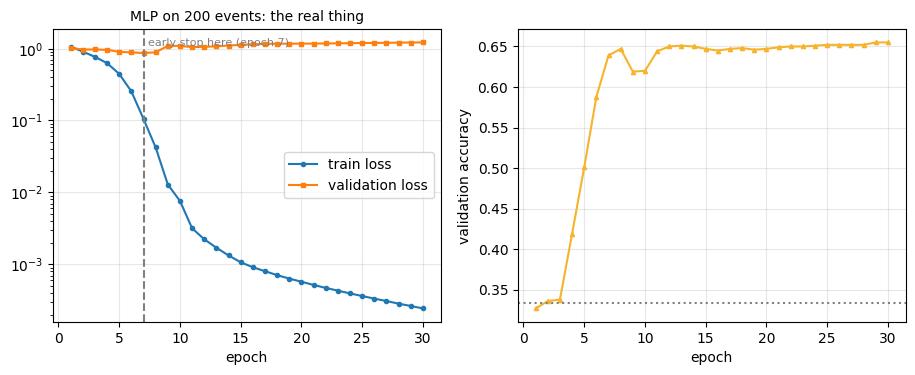

train loss  epoch 1 1.0617  ->  epoch 30 0.00024
val   loss  best 0.866 at epoch 7  ->  epoch 30 1.215


In [12]:
def make_mlp():
    return nn.Sequential(nn.Flatten(),
                         nn.Linear(ms.SIZE * ms.SIZE, 256), nn.ReLU(),
                         nn.Linear(256, 128), nn.ReLU(),
                         nn.Linear(128, 3))


torch.manual_seed(0)
mlp = make_mlp().to(DEVICE)
opt = torch.optim.Adam(mlp.parameters(), lr=1e-3)
curve = []
for ep in range(30):
    mlp.train()
    perm = torch.randperm(n_small)
    tot = 0.0
    for i in range(0, n_small, 32):
        b = perm[i:i + 32]
        if len(b) < 2:
            continue
        opt.zero_grad()
        loss = F.cross_entropy(mlp(X[b].to(DEVICE)), Y[b].to(DEVICE))
        loss.backward(); opt.step()
        tot += loss.item() * len(b)
    mlp.eval()
    with torch.no_grad():
        logits = torch.cat([mlp(XV[i:i + 256].to(DEVICE)).cpu()
                            for i in range(0, len(XV), 256)])
    curve.append((tot / n_small, float(F.cross_entropy(logits, YV)),
                  float((logits.argmax(1) == YV).float().mean())))

tr_l, va_l, va_a = zip(*curve)
best = int(np.argmin(va_l))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(range(1, 31), tr_l, "o-", ms=3, label="train loss")
ax[0].plot(range(1, 31), va_l, "s-", ms=3, label="validation loss")
ax[0].axvline(best + 1, ls="--", c="grey")
ax[0].text(best + 1.4, max(va_l) * 0.9, f"early stop here (epoch {best + 1})",
           fontsize=8, color="grey")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[0].set_title("MLP on 200 events: the real thing", fontsize=10)
ax[1].plot(range(1, 31), va_a, "^-", ms=3, color="#f7b32b")
ax[1].axhline(1 / 3, ls=":", c="grey")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("validation accuracy"); ax[1].grid(alpha=0.3)
plt.show()
print(f"train loss  epoch 1 {tr_l[0]:.4f}  ->  epoch 30 {tr_l[-1]:.5f}")
print(f"val   loss  best {min(va_l):.3f} at epoch {best + 1}  ->  epoch 30 {va_l[-1]:.3f}")

*That* is overfitting. The training loss goes to essentially zero — the MLP has
memorised all 200 events perfectly — while the validation loss reaches its
minimum early and then climbs, monotonically, and never comes back. Validation
accuracy plateaus far below what the CNN achieved on identical data.

Two things worth taking from the comparison:

- **The signature is the monotone divergence, not the first upturn.** Patient E
  also went "train down, validation up" for a few epochs. Only one of them was
  overfitting. Give it a few more epochs before you diagnose.
- **The CNN did not overfit these 200 events and the MLP did.** Same data, same
  optimiser, same budget. That is Notebook 0's argument arriving from a new
  direction: a good architectural prior is itself a regulariser, and often a far
  stronger one than anything you add to the loss.

### Fixes for the small-data regime

Now the remedies, trained for 24 epochs so that we are past the BatchNorm
transient and measuring generalisation rather than the artefact above.

E: 200 events, as-is               final val acc 0.938   (8 s)
E: + weight decay                  final val acc 0.934   (8 s)
E: + shift augmentation            final val acc 0.956   (7 s)
E: + both                          final val acc 0.986   (7 s)


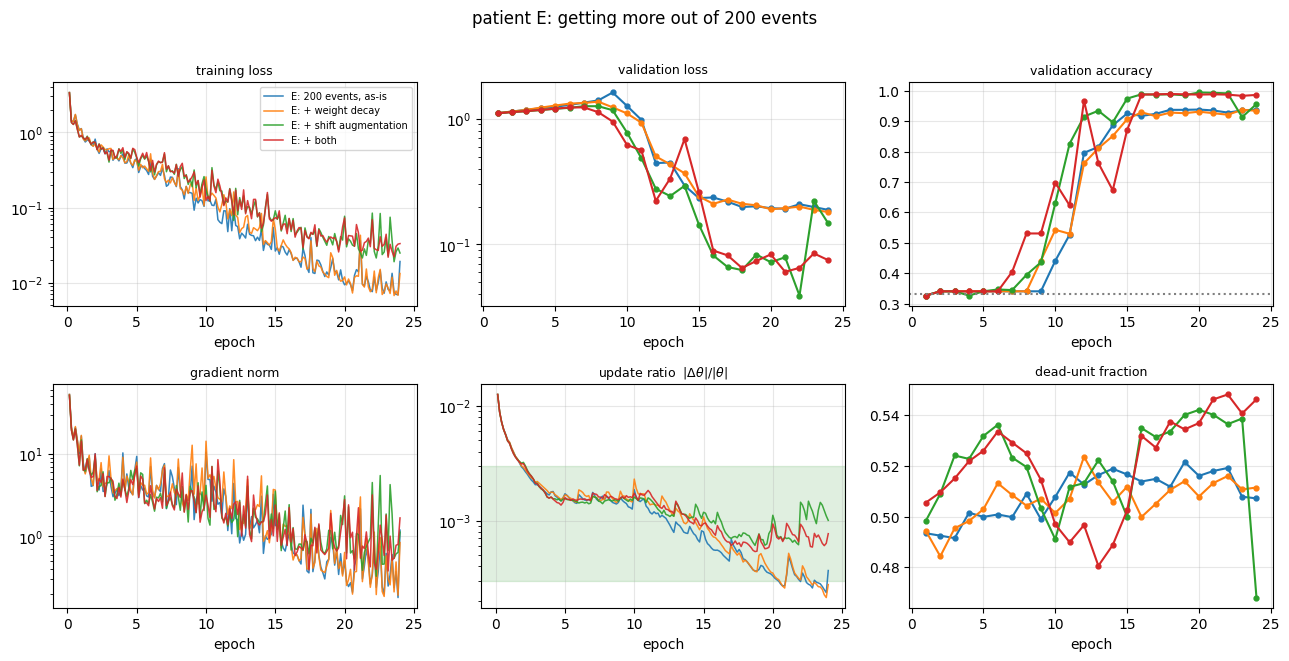

In [13]:
small = [
    experiment("E: 200 events, as-is",   n_train=200, epochs=24, bs=32),
    experiment("E: + weight decay",      n_train=200, epochs=24, bs=32,
               optimizer="adamw", weight_decay=1e-2),
    experiment("E: + shift augmentation", n_train=200, epochs=24, bs=32, augment=True),
    experiment("E: + both",              n_train=200, epochs=24, bs=32,
               optimizer="adamw", weight_decay=1e-2, augment=True),
]
plot_runs(small, "patient E: getting more out of 200 events", figsize=(13, 6.5))

**Data augmentation** is the big win, and it is worth understanding *why* in the
language of Notebook 0. We randomly translate each event during training. That
tells the model, through the data rather than through the architecture, that the
answer does not depend on position. It is a **soft inductive bias**: the same
prior a CNN's weight sharing encodes structurally, injected as extra examples
instead.

That comparison is the whole architecture-versus-augmentation trade-off:

| | architectural symmetry | augmentation |
|---|---|---|
| guarantee | exact (up to the caveats in Notebook 0) | approximate, learned |
| cost | must design the layer | a few lines, works with any model |
| data | none | needs enough capacity and epochs to absorb the extra variation |
| flexibility | fixed at design time | mix and match freely |

In practice you use both, and augmentation is where you encode the symmetries
that are too awkward to build into a layer. **Pick augmentations that reflect
real physical or detector-level variability** — translations, reflections if your
detector is symmetric, realistic noise, gain variation, dead channels. Do not
augment with transformations that never happen in your detector; you will just be
teaching the model to solve a harder problem than it faces.

**Weight decay** barely moves the needle here — the difference between the
with- and without- runs is comparable to the run-to-run scatter, so do not read
much into its sign. That is worth stating plainly rather than quietly implying it
helped: on this problem, the useful regulariser is the one that injects a real
symmetry, and the generic one does almost nothing.

**Early stopping** is the third fix and requires no code at all: keep the weights
from the epoch with the lowest validation loss. Note that on *these* runs it buys
almost nothing, because the validation loss never really turns back up — the CNN
is not overfitting 200 events. It was worth a great deal on the MLP curve above,
which is the situation early stopping was invented for.

One more thing to notice, because it is honest and it matters: with only 200
events the outcome is **unstable**. Run these four configurations again with a
different seed and the ordering can change. Small-data results are noisy, and a
single run is not evidence — which is checklist item 15 below.

## 4. Fixing A and B properly: find the learning rate, do not guess it

Patients A and B were both learning-rate failures, in opposite directions. There
is a cheap, reliable way to find the right value, and it takes less than one
epoch: **increase the learning rate exponentially over a few hundred steps and
plot the loss against it.**

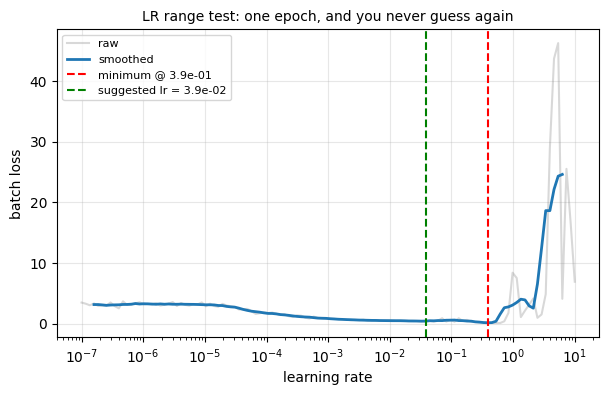

In [14]:
def lr_finder(model=None, lr_min=1e-7, lr_max=10.0, n_steps=120, bs=64):
    torch.manual_seed(0)
    model = (model if model is not None else make_net()).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr_min)
    lrs = np.logspace(np.log10(lr_min), np.log10(lr_max), n_steps)
    losses = []
    perm = torch.randperm(len(X))
    model.train()
    for k, lr in enumerate(lrs):
        for gp in opt.param_groups:
            gp["lr"] = float(lr)
        b = perm[(k * bs) % (len(X) - bs):(k * bs) % (len(X) - bs) + bs]
        opt.zero_grad()
        loss = F.cross_entropy(model(X[b].to(DEVICE)), Y[b].to(DEVICE))
        loss.backward(); opt.step()
        losses.append(loss.item())
    return lrs, np.array(losses)


lrs, losses = lr_finder()
smooth = np.convolve(losses, np.ones(7) / 7, mode="same")
best = int(np.argmin(smooth[3:-3])) + 3

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(lrs, losses, alpha=0.3, color="grey", label="raw")
ax.semilogx(lrs[3:-3], smooth[3:-3], lw=2, label="smoothed")
ax.axvline(lrs[best], color="red", ls="--", label=f"minimum @ {lrs[best]:.1e}")
ax.axvline(lrs[best] / 10, color="green", ls="--",
           label=f"suggested lr = {lrs[best] / 10:.1e}")
ax.set_xlabel("learning rate"); ax.set_ylabel("batch loss")
ax.set_title("LR range test: one epoch, and you never guess again", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

Read it like a resonance curve. At the left nothing happens (patient B). In the
middle the loss falls steeply. Then it turns sharply upward as the steps become
too large (patient A). **Take roughly one tenth of the minimum**: you want to be
on the steep part with margin, not at the edge of instability.

Note where the minimum sits — around $10^{-1}$ — and where we would normally set
the learning rate: $10^{-3}$. Two orders of magnitude below the failure point.
That gap is not wasted; it is the margin that keeps training stable once the loss
surface gets harder later in training.

### Schedules and warmup

The right learning rate is not one number, because the right number changes as
training proceeds. Early on you want large steps to cover ground; later you want
small steps to settle into a minimum. Hence **schedules**.

**Cosine decay** is the standard choice, and it is worth understanding rather
than copying. The learning rate follows a half-period of a cosine from its
maximum down to (almost) zero over the course of training:

$$\eta(t) = \eta_{\max}\cdot\tfrac{1}{2}\left[1 + \cos\!\left(\pi \frac{t}{T}\right)\right]$$

where $t$ is the current step and $T$ the total. Three properties earn it its
place:

- **It spends a long time near $\eta_{\max}$.** The cosine is flat at the top, so
  you get an extended high-learning-rate phase to explore, rather than decaying
  away from it immediately.
- **It ends very close to zero, smoothly.** The last stretch of training is what
  determines where in the minimum you actually land. SGD with a finite learning
  rate does not sit at a minimum — it bounces around it in a region whose size
  grows with $\eta$. Annealing to zero shrinks that region, so the final weights
  settle instead of rattling. This is the part that most improves the final
  number, and it is why "train at constant LR then stop" leaves accuracy behind.
- **There are no discontinuities.** The older recipe — step decay, dividing the
  LR by 10 at fixed epochs — works, but each drop is a shock to the optimiser
  state and the drop times are three more hyperparameters to tune. Cosine has
  one: $\eta_{\max}$.

A useful way to hold it: the high-LR phase decides *which* basin you end up in;
the low-LR phase decides *how precisely* you sit in it.

**Warmup** (starting small and ramping up over the first few hundred steps)
deserves a specific comment. It exists because at initialisation an adaptive 
optimiser has not yet accumulated reliable gradient statistics; a large step 
taken then can wreck the model before training begins (patient A, in miniature). 
It became standard when batches got large and **paired with a large learning rate**. 
It is not a universal law: you may not always need it but it is particularly effective
for training a Transformer architecture.

**One-cycle** is warmup and cosine decay glued together, which is what
`OneCycleLR` gives us. Here is the actual shape.

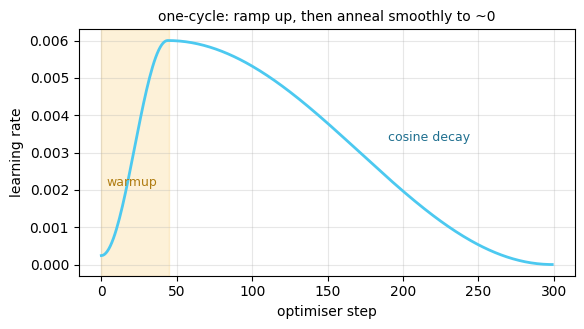

In [15]:
demo_opt = torch.optim.SGD([torch.zeros(1, requires_grad=True)], lr=6e-3)
demo_sched = torch.optim.lr_scheduler.OneCycleLR(
    demo_opt, max_lr=6e-3, total_steps=300, pct_start=0.15)
shape = []
for _ in range(300):
    shape.append(demo_opt.param_groups[0]["lr"])
    demo_opt.step(); demo_sched.step()

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(shape, lw=2, color="#4cc9f0")
ax.axvspan(0, 45, color="#f7b32b", alpha=0.18)
ax.text(20, max(shape) * 0.35, "warmup", fontsize=9, color="#b07d12", ha="center")
ax.text(190, max(shape) * 0.55, "cosine decay", fontsize=9, color="#1f6f8f")
ax.set_xlabel("optimiser step"); ax.set_ylabel("learning rate")
ax.set_title("one-cycle: ramp up, then anneal smoothly to ~0", fontsize=10)
ax.grid(alpha=0.3)
plt.show()

constant lr 1e-3                   final val acc 0.995   (12 s)
one-cycle (warmup+cos)             final val acc 0.997   (12 s)


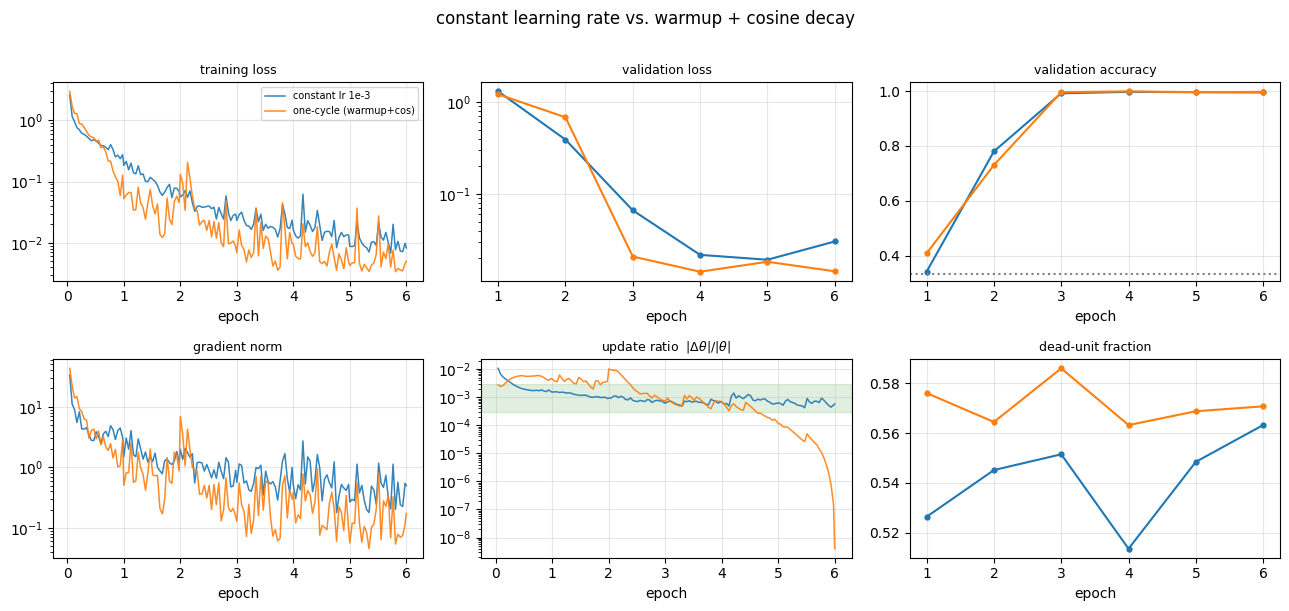

In [16]:
sched_runs = [
    experiment("constant lr 1e-3",      lr=1e-3),
    experiment("one-cycle (warmup+cos)", lr=6e-3, scheduler="cosine"),
]
plot_runs(sched_runs, "constant learning rate vs. warmup + cosine decay", figsize=(13, 6))

### Optimisers, briefly

- **SGD with momentum.** One global learning rate for every parameter. Sensitive
  to that choice and to input scaling. Still produces the best final numbers on
  large vision benchmarks when tuned carefully.
- **Adam.** Keeps a running estimate of each parameter's gradient magnitude and
  divides by it, so every parameter gets its own effective step size. Vastly
  easier to get working. This robustness is why it is the default, and it is also
  why some classic failure modes have quietly disappeared — see the next section.
- **AdamW.** Adam with weight decay applied directly to the weights rather than
  folded into the gradient. The original Adam formulation couples decay to the
  adaptive scaling, which is not what anyone intended. **If you want weight decay
  with Adam, use AdamW.** This is a genuine bug fix, not a preference.

Sensible default for anything in this lecture: **AdamW, lr $10^{-3}$, weight
decay $10^{-2}$, cosine schedule.** Start there, run the LR finder, move on.

SGD+momentum lr=1e-2               final val acc 0.987   (12 s)
Adam lr=1e-3                       final val acc 0.993   (12 s)
AdamW lr=1e-3 wd=1e-2              final val acc 0.986   (12 s)


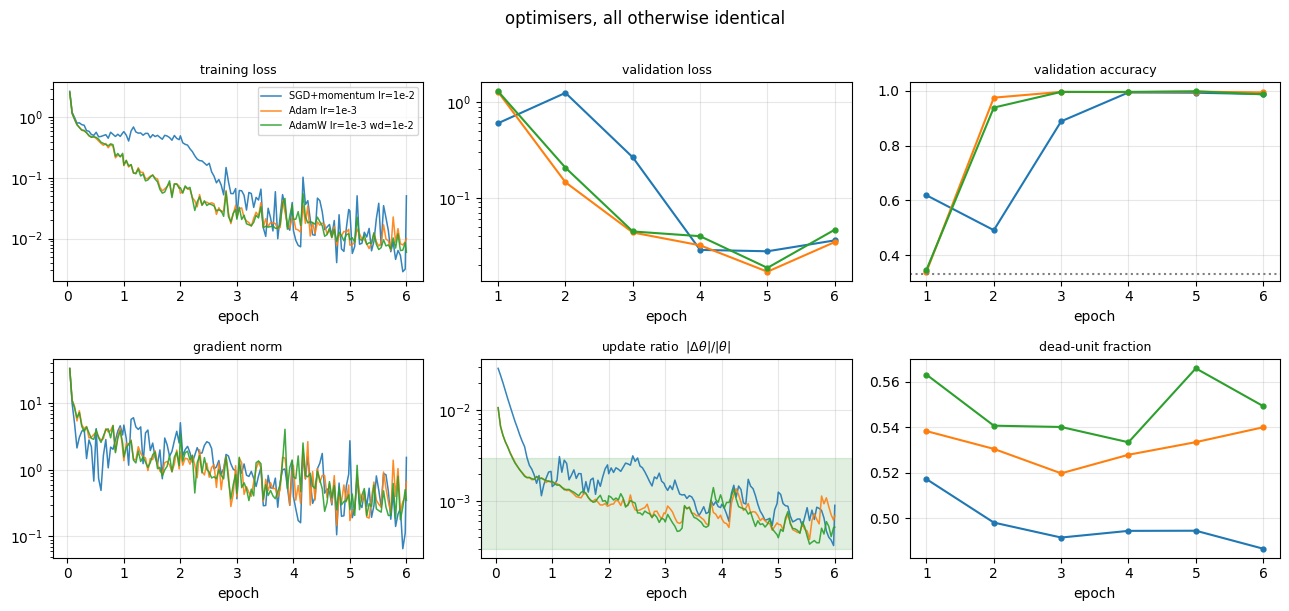

In [17]:
plot_runs([experiment("SGD+momentum lr=1e-2", lr=1e-2, optimizer="sgd"),
           experiment("Adam lr=1e-3", lr=1e-3, optimizer="adam"),
           experiment("AdamW lr=1e-3 wd=1e-2", lr=1e-3, optimizer="adamw",
                      weight_decay=1e-2)],
          "optimisers, all otherwise identical", figsize=(13, 6))

## 5. A classic bug that refused to reproduce

Every tutorial, including the first draft of this one, contains the warning:
*always normalise your inputs, or training will fail*. Our raw charges run to
~140. So let us commit the sin deliberately and watch it burn.

normalised inputs, BN              final val acc 0.963   (12 s)
RAW inputs, BN                     final val acc 0.992   (12 s)
RAW inputs, no BN                  final val acc 0.992   (10 s)
RAW inputs, no BN, SGD             final val acc 0.673   (10 s)
normalised, no BN, SGD             final val acc 0.327   (10 s)


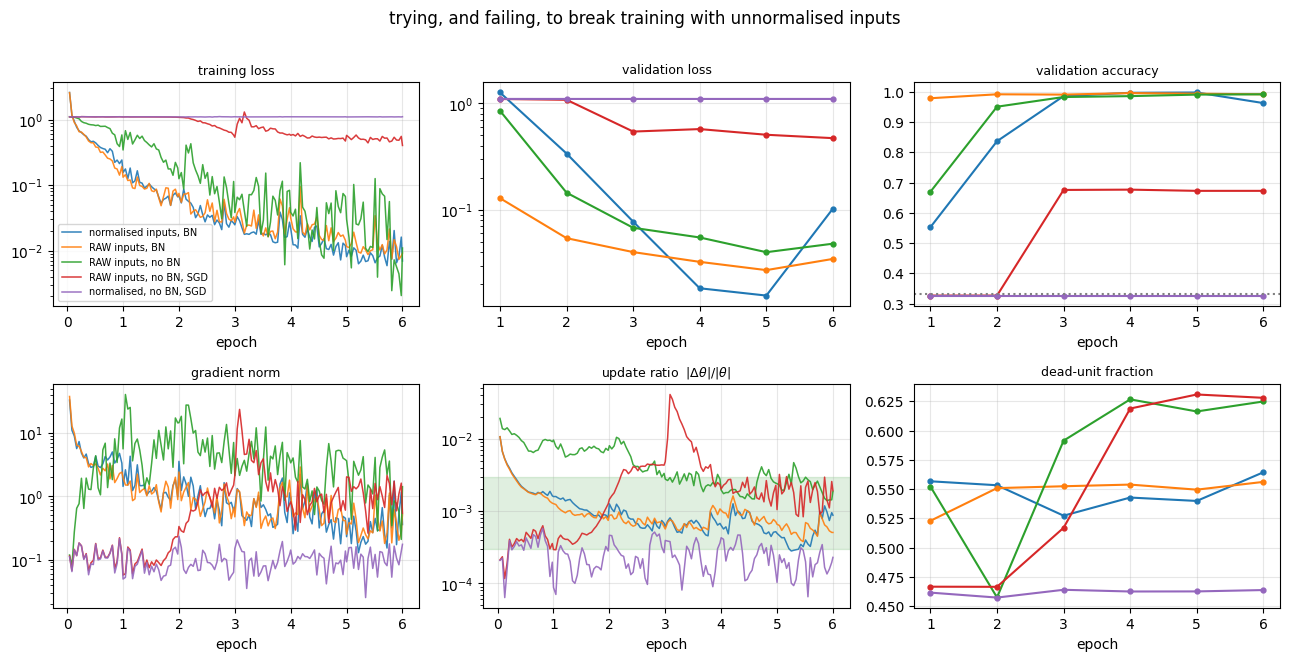

In [18]:
norm_test = [
    experiment("normalised inputs, BN",     raw_inputs=False),
    experiment("RAW inputs, BN",            raw_inputs=True),
    experiment("RAW inputs, no BN",         raw_inputs=True,
               model=lambda: make_net(4, norm=False)),
    experiment("RAW inputs, no BN, SGD",    raw_inputs=True, optimizer="sgd", lr=1e-2,
               model=lambda: make_net(4, norm=False)),
    experiment("normalised, no BN, SGD",    raw_inputs=False, optimizer="sgd", lr=1e-2,
               model=lambda: make_net(4, norm=False)),
]
plot_runs(norm_test, "trying, and failing, to break training with unnormalised inputs",
          figsize=(13, 6.5))

It did not burn. Feeding raw charges of order 100 into a BatchNorm network costs
a few percent of accuracy; removing BatchNorm *and* keeping raw inputs costs
essentially nothing under Adam. And the run that actually fails — collapsing to
chance — is the one with **normalised** inputs, no BatchNorm, and plain SGD. The
supposed remedy is present in the only configuration that breaks.

Two of the three results are easy. **BatchNorm renormalises immediately**: the
first normalisation layer rescales activations to zero mean and unit variance
regardless of what came in, so an input scale factor is absorbed in the first
block. Normalisation layers are partly a *substitute* for careful input scaling,
and that is a large part of why they made networks so much easier to train.
**Adam divides each parameter's step by a running estimate of that parameter's
own gradient magnitude**, so a global rescaling of the inputs largely cancels.

The interesting one is the failure. Why is *normalised, no BN, SGD* worse than
*raw, no BN, SGD*?

The tempting answer — the one this notebook gave in an earlier draft — is that
normalising shrinks the gradients, so the effective step size is too small, so we
simply need a larger learning rate. That answer is wrong, and it is worth showing
that it is wrong rather than quietly correcting it.

In [19]:
print("normalised inputs, no BatchNorm, SGD -- sweep the learning rate")
for lr in (1e-3, 1e-2, 1e-1, 1.0):
    r = experiment(f"  normalised, SGD lr={lr}", raw_inputs=False, optimizer="sgd",
                   lr=lr, model=lambda: make_net(4, norm=False), epochs=4, light=True)
print("\nRAW inputs, same network, for comparison")
_ = experiment("  RAW, SGD lr=0.01", raw_inputs=True, optimizer="sgd", lr=1e-2,
               model=lambda: make_net(4, norm=False), epochs=4, light=True)

normalised inputs, no BatchNorm, SGD -- sweep the learning rate
  normalised, SGD lr=0.001         final val acc 0.327   (6 s)
  normalised, SGD lr=0.01          final val acc 0.327   (7 s)
  normalised, SGD lr=0.1           final val acc 0.332   (7 s)
  normalised, SGD lr=1.0           final val acc 0.332   (6 s)

RAW inputs, same network, for comparison
  RAW, SGD lr=0.01                 final val acc 0.673   (6 s)


No learning rate rescues it. Four orders of magnitude, all at chance. So this is
not a global step-size problem, and "just raise the LR" is not the fix.

Measure the gradients instead.

In [20]:
def first_and_last_grad(raw):
    torch.manual_seed(0)
    model = make_net(4, norm=False).to(DEVICE)
    xb = (torch.tensor(train["image"])[:64, None] if raw else X[:64])
    F.cross_entropy(model(xb.to(DEVICE)), Y[:64].to(DEVICE)).backward()
    g = [float(p.grad.norm()) for p in model.parameters() if p.dim() == 4]
    return g[0], g[-1]


print(f"{'inputs':<14}{'first conv |g|':>16}{'last conv |g|':>16}{'ratio':>12}")
print("-" * 58)
for tag, raw in [("RAW", True), ("normalised", False)]:
    f_, l_ = first_and_last_grad(raw)
    print(f"{tag:<14}{f_:>16.2e}{l_:>16.2e}{l_ / f_:>12.0f}x")

inputs          first conv |g|   last conv |g|       ratio
----------------------------------------------------------
RAW                   5.64e-04        3.89e-02          69x
normalised            1.52e-06        3.85e-02       25317x


There is the mechanism.

The gradient with respect to the **first** convolution's weights is proportional
to the magnitude of its input — that is just the chain rule,
$\partial L/\partial W_1 \propto x$. Normalising the inputs divides that gradient
by the charge scale. The **deeper** layers barely notice, because their inputs are
activations whose scale is set by the weights rather than by the raw data.

So normalising does not shrink the gradients *uniformly*. It shrinks them at the
input end only, and thereby stretches the spread of gradient magnitudes **across
depth** by a large factor.

Now recall what plain SGD does: it multiplies every gradient by **one global
learning rate**. A single number cannot serve a network whose layers need steps
differing by four orders of magnitude. Set it large enough to move the first
layer and you blow up the last; set it small enough for the last and the first
never moves. That is precisely what the sweep above shows — there is no good
value, because the problem is not the value.

This should feel familiar: it is **patient C in a different disguise**. There the
gradient spread across depth came from stacking twenty layers; here it comes from
the input scale. Same disease, same two cures:

- **Normalisation layers** re-equalise the activation scale at every depth, which
  re-equalises the gradients — and indeed *RAW inputs, BN* trains fine.
- **Per-parameter optimisers** give every parameter its own effective step size,
  which is exactly immunity to a per-layer spread. Swap SGD for Adam on the
  normalised, no-BN network and it trains.

Raw inputs "work" here only by accident: they happen to compress the spread
enough that one global learning rate can serve, and only in a narrow window
(lr $=10^{-2}$ works, $10^{-3}$ and $10^{-1}$ do not).

So has the rule been debunked? No — it has been **scoped**, and the scope is the
useful part:

- Input normalisation matters most when you have **neither** an adaptive
  optimiser **nor** normalisation layers. That was the world the rule was written
  for.
- It still matters for **numerical range**: inputs of order $10^6$, or mixed
  channels spanning wildly different scales, will cause trouble regardless.
- It matters much more for **targets** than for inputs. There is no BatchNorm on
  your regression target. A target of order $10^3$ against a cross-entropy of
  order 1 will silently dominate a multi-task loss — which is exactly why we
  standardised the energy target in Notebook 1.

**The transferable habit:** when you inherit a rule, find out what it is
protecting you from, then check whether that mechanism is present in your setup.
Half the folklore in deep learning is a correct response to a problem that a
later invention has already solved.

## 6. Why these tricks, and why then?

Every technique in this notebook was invented to solve a specific problem that
appeared at a specific scale. Seen as a list they are arbitrary; seen as a
history they are almost inevitable.

| era | what changed | the problem | the response |
|---|---|---|---|
| pre-2012 | networks a few layers deep | training is unreliable at all | careful layer-wise pretraining |
| 2012 | AlexNet, GPUs, ImageNet | saturating sigmoids kill gradients; 60 M parameters overfit | **ReLU**, **dropout**, aggressive **augmentation** |
| 2015 | networks 20+ layers | internal activation scales drift; deep nets will not converge | **BatchNorm** |
| 2015 | ResNet, 50–150 layers | gradients vanish across depth (the plot in §3) | **residual connections** |
| 2017 | transformers, variable-length inputs | batch statistics are meaningless across a batch of different-length sequences | **LayerNorm** |
| 2018– | very large batches on many GPUs | fewer, larger steps; a bad early step is fatal | **warmup**, **cosine schedules** |
| 2019– | large models, weight decay matters | Adam's decay coupling is wrong | **AdamW** |
| 2020s | huge models, memory-bound | activations do not fit | **mixed precision**, **gradient checkpointing**, **gradient accumulation** |

Two observations, and they are the reason this table is here.

**Dropout has quietly faded.** It was essential in 2012, when the recipe was a
large MLP head, no normalisation, and a small dataset. Modern convolutional and
transformer architectures use BatchNorm or LayerNorm, heavy augmentation, weight
decay, and far more data — and dropout in convolutional layers now usually hurts.
It survives in fully-connected heads, in transformers at modest rates, and as
**MC-dropout** for cheap uncertainty estimates, which is a genuinely useful trick
for physics. But if you learned "always add dropout", that advice expired.

**Nothing here is a law of nature.** Each row is an empirical response to a
particular scaling regime. When your regime differs — sparse data, tiny batches,
a detector with 2 % occupancy — the appropriate response may differ too. That is
not a licence to ignore the table. It is a reason to run the ablation, which
costs you twenty minutes and settles the question for your problem.

## 7. The checklist

Print this. When a model will not train, work down it in order — the entries are
sorted by (probability × cheapness to check).

**Before you train**
1. Look at your data. Plot ten events. Print min/max/mean of inputs and targets.
2. Check the label distribution, and compute what a constant predictor scores.
3. Compute your receptive field. Can the model physically see the evidence?
4. **Overfit 20 events on purpose.** If the model cannot drive the training loss
   to ~0 on 20 examples, something is broken in your code, not your
   hyperparameters. This is the single highest-value five minutes in the list.

**When it will not learn** (training loss flat)
5. Is the loss pinned at $\ln(\text{n classes})$? The model has collapsed.
6. Check the **update ratio**. Above $10^{-2}$: lower the LR. Below $10^{-5}$:
   raise it. Run the LR finder.
7. Check the gradient norm across depth. Vanishing? Add normalisation and
   residual connections.
8. Is the data shuffled? Really?
9. Check dead-unit fraction. Climbing towards 1: lower the LR, check the init.

**When it learns but does not generalise** (train down, val up)
10. First rule out the impostors. Does train/eval differ (BatchNorm running
    statistics, dropout, a preprocessing step applied to only one set)? Does the
    gap persist for many more epochs, or reverse? Genuine overfitting is a
    *monotone* divergence.
11. More data, or augmentation that reflects real detector variability.
12. Weight decay (with AdamW), early stopping.
13. Check for leakage between train and validation — the same event, or events
    from the same simulation file, on both sides.
14. Build a test set that varies what you claim to be invariant to (Notebook 0).

**Always**
15. Fix the seed, log everything, change one thing at a time.
16. A single training run is one sample, not a measurement. Repeat before you
    believe a small difference.

## 8. Takeaways

1. **Log five things, not one**: train loss, val loss, gradient norm, update
   ratio, dead fraction. The update ratio has a memorable target, $\sim10^{-3}$.
2. **Learning rate first, always.** Two of five patients were LR failures, in
   opposite directions, and they look alike until you check the update ratio.
   Use the LR range test; it costs one epoch.
3. **Depth is only possible because of normalisation and residual connections.**
   Nearly ten orders of magnitude of gradient decay, measured, in a 21-layer
   plain net. Either mechanism alone fixes it here; both are standard because
   they stop being redundant as you scale.
4. **Shuffle your data.** Data arrives sorted, and a correlated batch breaks both
   SGD and BatchNorm.
5. **"Train down, validation up" is not automatically overfitting.** Patient E
   showed that curve and was actually a BatchNorm running-statistics artefact.
   Before diagnosing, list everything that differs between your training and
   evaluation code paths — and give it more epochs, because genuine overfitting
   does not reverse.
6. **Augmentation is a soft inductive bias** — the same prior as an architectural
   symmetry, injected through data.
7. **Scope your rules.** The classic input-normalisation failure would not
   reproduce here, for reasons worth knowing.

## 9. Exercises

1. **Diagnose a sixth patient.** Delete `opt.zero_grad()` from `experiment` and
   run it. Predict the signature first: gradients now accumulate across steps.
2. **Overfit 20 events.** Item 4 on the checklist. Confirm you can reach ~0
   training loss, then break something (wrong label dtype, a detached tensor) and
   confirm you cannot.
3. **How deep before it breaks?** Sweep `n_blocks` from 4 to 20 without
   normalisation or residuals, and plot final accuracy against depth. Where is
   the cliff? Now repeat with residuals on.
4. **Batch size and BatchNorm.** Rerun the healthy configuration with
   `bs=2, 8, 64, 256`, keeping the number of epochs fixed. What happens, and
   would `nn.GroupNorm` behave differently? (You may find BatchNorm more robust
   here than folklore predicts — if so, work out why, as in §5.)
5. **Augment badly on purpose.** Add 90° rotations to the augmentation. Our
   detector has no such symmetry — the drift direction is physically special.
   Does it help, hurt, or do nothing? What does that tell you about choosing
   augmentations from physics rather than from a library's default list?